# 1. Подготовка окружения и загрузка данных

Установим CatBoost для обучения основной модели и Optuna для подбора гиперпараметров

In [ ]:
%pip install -q catboost==1.2.8 optuna==4.5.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 9.5 MB/s eta 0:00:00


Импортируем библиотеки для обработки данных, визуализации, валидации и обучения моделей

In [120]:
import os
import platform
import random
from importlib.metadata import version
from pathlib import Path

import catboost
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import sklearn

from catboost import CatBoostClassifier
from google.colab import files
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, roc_auc_score
from metric import precision_at_recall

Зафиксируем random_state и основные сиды, чтобы результаты решения воспроизводились, а также наведем небольшую красоту для отображения таблиц, цифр и графиков

In [121]:
RANDOM_STATE = 42

os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid")

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"catboost: {catboost.__version__}")
print(f"optuna: {optuna.__version__}")

Python: 3.13.15
pandas: 2.2.3
numpy: 2.1.3
scikit-learn: 1.6.1
catboost: 1.2.8
optuna: 4.5.0


Сохраним версии используемых библиотек в requirements.txt, чтобы решение можно было воспроизвести

In [122]:
requirements = [
    f"numpy=={np.__version__}",
    f"pandas=={pd.__version__}",
    f"matplotlib=={version('matplotlib')}",
    f"seaborn=={version('seaborn')}",
    f"scikit-learn=={sklearn.__version__}",
    f"catboost=={catboost.__version__}",
    f"optuna=={optuna.__version__}",
]

Path("requirements.txt").write_text(
    "\n".join(requirements) + "\n",
    encoding="utf-8",
)

print("requirements.txt создан")

requirements.txt создан


Зададим пути к файлам и убедимся, что все необходимые данные доступны

In [125]:
DATA_DIR = Path("data")

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
EVENTS_PATH = DATA_DIR / "events.csv.gz"
SAMPLE_SUBMISSION_PATH = Path("submission.csv")
METRIC_PATH = Path("metric.py")

required_paths = [
    TRAIN_PATH,
    TEST_PATH,
    EVENTS_PATH,
    SAMPLE_SUBMISSION_PATH,
    METRIC_PATH,
]

missing_paths = [str(path) for path in required_paths if not path.exists()]
assert not missing_paths, f"Не найдены файлы: {missing_paths}"

Загрузим обучающую и тестовую выборки, события и пример файла с предсказаниями

In [126]:
meta_date_columns = ["cookie_created_at", "window_start_ts", "window_end_ts"]

train = pd.read_csv(TRAIN_PATH, parse_dates=meta_date_columns)
test = pd.read_csv(TEST_PATH, parse_dates=meta_date_columns)
events = pd.read_csv(EVENTS_PATH, parse_dates=["event_ts"])
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

Проверим размеры загруженных таблиц

In [127]:
print(f"train: {train.shape}")
print(f"test: {test.shape}")
print(f"events: {events.shape}")
print(f"sample_submission: {sample_submission.shape}")

train: (11091, 5)
test: (4909, 4)
events: (328905, 14)
sample_submission: (4909, 2)


# 2. EDA

In [128]:
dataframes_eda = {
    "train": train,
    "test": test,
    "events": events,
    "sample_submission": sample_submission,
}

Посмотрим на названия колонок и типы данных в каждой таблице

In [129]:
for name, df in dataframes_eda.items():
    print(name)
    display(pd.DataFrame({"Колонка": df.columns,
                          "Тип данных": df.dtypes.astype(str).values,
                          "Количество уникальных значений": df.nunique(dropna=True).values}))
    print()

train


,Колонка,Тип данных,Количество уникальных значений
0,cookie_id,object,11091
1,cookie_created_at,datetime64[ns],11085
2,window_start_ts,datetime64[ns],14
3,window_end_ts,datetime64[ns],14
4,target,int64,2



test


,Колонка,Тип данных,Количество уникальных значений
0,cookie_id,object,4909
1,cookie_created_at,datetime64[ns],4908
2,window_start_ts,datetime64[ns],7
3,window_end_ts,datetime64[ns],7



events


,Колонка,Тип данных,Количество уникальных значений
0,cookie_id,object,16000
1,event_ts,datetime64[ns],285094
2,eid,int64,10
3,event_name,object,10
4,platform,object,11
5,user_agent,object,148
6,item_id,float64,53856
7,item_category,object,15
8,item_location,object,40
9,seller_type,object,2



sample_submission


,Колонка,Тип данных,Количество уникальных значений
0,cookie_id,object,4909
1,score,float64,4908


Проверим уникальность cookie_id, пересечения между train и test и наличие событий для каждой куки

In [130]:
train_ids = set(train["cookie_id"])
test_ids = set(test["cookie_id"])
event_ids = set(events["cookie_id"])
all_ids = train_ids | test_ids

cookie_checks = {
    "Дубликаты cookie_id в train": train["cookie_id"].duplicated().sum(),
    "Дубликаты cookie_id в test": test["cookie_id"].duplicated().sum(),
    "Пересечения cookie_id между train и test": len(train_ids & test_ids),
    "Куки без событий": len(all_ids - event_ids),
    "Лишние куки в events": len(event_ids - all_ids),
}

display(pd.Series(cookie_checks, name="Количество"))

,Количество
Дубликаты cookie_id в train,0
Дубликаты cookie_id в test,0
Пересечения cookie_id между train и test,0
Куки без событий,0
Лишние куки в events,0


В train содержится 11 091 уникальная кука, в test — 4 909, пересечений между выборками нет, при этом для каждой куки есть хотя бы одно событие

Посмотрим на распределение целевой переменной и оценим дисбаланс классов

,Количество,Доля
target,,
0,10192,0.9189
1,899,0.0811


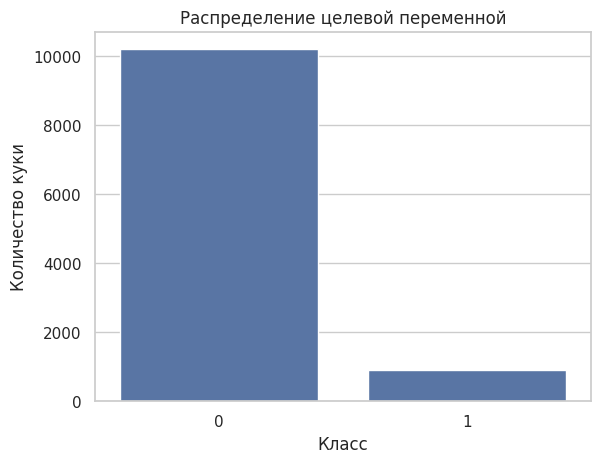

In [131]:
target_distribution = train["target"].value_counts().sort_index().to_frame("Количество")
target_distribution["Доля"] = target_distribution["Количество"] / len(train)
display(target_distribution.round(4))

sns.countplot(data=train, x="target")
plt.title("Распределение целевой переменной")
plt.xlabel("Класс")
plt.ylabel("Количество куки")
plt.show()

Положительный класс представлен 899 куками и занимает около 8,11% train, поэтому accuracy не подходит для оценки модели, а при обучении и валидации важно учитывать сильный дисбаланс классов

Проверим временные границы выборок, длину окон наблюдения и изменение доли ботов по дням

,Выборка,Начало периода,Конец периода,"Минимальная длина окна, ч","Максимальная длина окна, ч"
0,train,2026-04-06,2026-04-19,24.0000,24.0000
1,test,2026-04-20,2026-04-26,24.0000,24.0000


,Дата,Количество куки,Количество ботов,Доля ботов
0,2026-04-06,772,68,0.0881
1,2026-04-07,797,59,0.0740
2,2026-04-08,834,70,0.0839
3,2026-04-09,902,66,0.0732
4,2026-04-10,912,82,0.0899
5,2026-04-11,896,79,0.0882
6,2026-04-12,817,67,0.0820
7,2026-04-13,843,53,0.0629
8,2026-04-14,826,70,0.0847
9,2026-04-15,801,65,0.0811


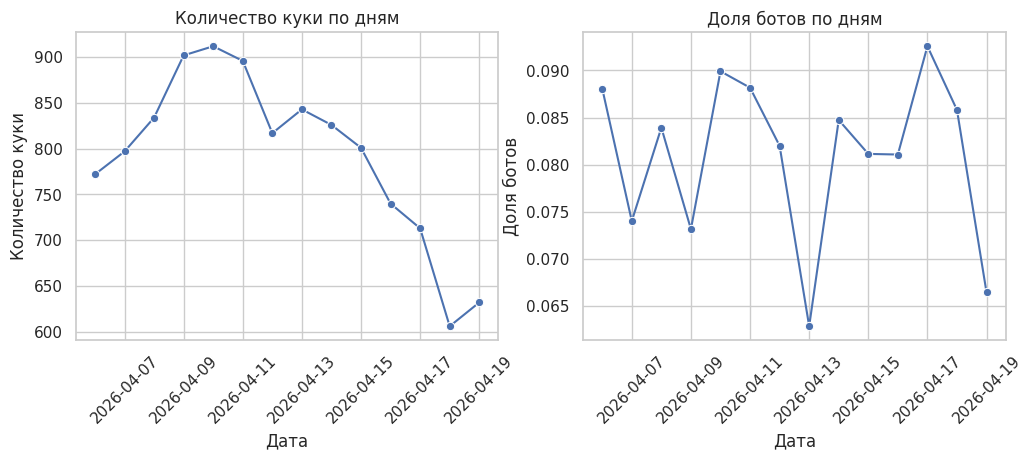

In [132]:
time_rows = []

for name, df in {"train": train, "test": test}.items():
    window_hours = (df["window_end_ts"] - df["window_start_ts"]).dt.total_seconds() / 3600
    time_rows.append({
        "Выборка": name,
        "Начало периода": df["window_start_ts"].min(),
        "Конец периода": df["window_start_ts"].max(),
        "Минимальная длина окна, ч": window_hours.min(),
        "Максимальная длина окна, ч": window_hours.max(),
    })

time_overview = pd.DataFrame(time_rows)
display(time_overview)

daily_train = train.assign(window_date=train["window_start_ts"].dt.date)
daily_train = daily_train.groupby("window_date")["target"].agg(["count", "sum", "mean"]).reset_index()
daily_train.columns = ["Дата", "Количество куки", "Количество ботов", "Доля ботов"]
display(daily_train)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(data=daily_train, x="Дата", y="Количество куки", marker="o", ax=axes[0])
sns.lineplot(data=daily_train, x="Дата", y="Доля ботов", marker="o", ax=axes[1])
axes[0].set_title("Количество куки по дням")
axes[1].set_title("Доля ботов по дням")
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
plt.show()

Все окна имеют длину ровно 24 часа, train охватывает период с 6 по 19 апреля 2026 года, а test начинается 20 апреля, поэтому далее будем использовать временную валидацию

Теперь определим, какие события действительно попадают в суточные окна наблюдения

In [133]:
meta_eda = pd.concat([
    train.assign(split="train"),
    test.assign(target=np.nan, split="test"),
], ignore_index=True)

window_columns = ["cookie_id", "window_start_ts", "window_end_ts", "split", "target"]
events_eda = events.merge(meta_eda[window_columns], on="cookie_id", how="left")
events_eda["in_window"] = (
    (events_eda["event_ts"] >= events_eda["window_start_ts"])
    & (events_eda["event_ts"] < events_eda["window_end_ts"])
)

window_summary = {
    "Всего событий": len(events_eda),
    "Событий внутри окна": events_eda["in_window"].sum(),
    "Событий вне окна": (~events_eda["in_window"]).sum(),
    "Событий train внутри окна": ((events_eda["split"] == "train") & events_eda["in_window"]).sum(),
    "Событий test внутри окна": ((events_eda["split"] == "test") & events_eda["in_window"]).sum(),
}
display(pd.Series(window_summary, name="Количество"))

event_window_table = pd.crosstab(events_eda["event_name"], events_eda["in_window"])
event_window_table = event_window_table.rename(columns={False: "Вне окна", True: "В окне"})
display(event_window_table.sort_values("Вне окна", ascending=False))

events_window_eda = events_eda[events_eda["in_window"]].copy()

,Количество
Всего событий,328905
Событий внутри окна,288126
Событий вне окна,40779
Событий train внутри окна,198436
Событий test внутри окна,89690


in_window,Вне окна,В окне
event_name,,
item_view,12731,108086
search_results_view,10604,89798
captcha_shown,7928,0
photo_swipe,3433,33084
seller_page_view,1861,15542
favorite_add,1753,17296
contact_phone_show,1028,10288
login,606,5661
contact_chat_open,577,5548


Из 328 905 событий в окно попадают 288 126: 198 436 для train и 89 690 для test. Вне окна остаются 40 779 событий. Все 7 928 событий captcha_shown находятся вне окна, поэтому использовать капчу как признак нельзя

Проверим, что после фильтрации внутри окна у каждой куки осталось хотя бы одно событие

In [134]:
window_events_per_cookie = events_window_eda.groupby(["split", "cookie_id"]).size().reset_index(name="n_events")
cookie_coverage = meta_eda[["cookie_id", "split"]].merge(window_events_per_cookie, on=["cookie_id", "split"], how="left")
cookie_coverage["n_events"] = cookie_coverage["n_events"].fillna(0).astype(int)

coverage_summary = cookie_coverage.groupby("split")["n_events"].agg(["count", "min", "median", "mean", "max"])
display(coverage_summary.round(2))
print("Куки без событий внутри окна:", (cookie_coverage["n_events"] == 0).sum())

,count,min,median,mean,max
split,,,,,
test,4909,1,12.0000,18.2700,191
train,11091,1,12.0000,17.8900,169


Куки без событий внутри окна: 0


После временной фильтрации у каждой из 16 000 куки остается хотя бы одно событие, поэтому ни одна строка train или test не потеряется при построении признаков

Оценим количество точных дубликатов и проверим, отсортированы ли события каждой куки по времени в исходном файле

In [135]:
monotonic_by_cookie = events.groupby("cookie_id", sort=False)["event_ts"].apply(lambda x: x.is_monotonic_increasing)

quality_checks = {
    "Лишние точные дубликаты во всем файле": events.duplicated().sum(),
    "Лишние точные дубликаты внутри окон": events_window_eda[events.columns].duplicated().sum(),
    "Всего куки": len(monotonic_by_cookie),
    "Куки с хронологическим порядком строк": monotonic_by_cookie.sum(),
    "Куки с нарушенным порядком строк": (~monotonic_by_cookie).sum(),
}

display(pd.Series(quality_checks, name="Значение"))

,Значение
Лишние точные дубликаты во всем файле,4863
Лишние точные дубликаты внутри окон,4293
Всего куки,16000
Куки с хронологическим порядком строк,559
Куки с нарушенным порядком строк,15441


В данных есть 4 863 лишних точных дубликата, из них 4 293 находятся внутри окон. Только у 559 из 16 000 куки события изначально идут по времени, поэтому перед расчетом интервалов их нужно сортировать по cookie_id и event_ts. Перед построением признаков точные дубликаты удалим, оставив по одному событию

Посмотрим на долю пропусков по столбцам среди событий внутри окна

,0
search_query,0.6883
search_page,0.6883
pointer_x,0.6680
pointer_y,0.6680
seller_type,0.3914
item_id,0.3313
item_category,0.0780
item_location,0.0496
user_agent,0.0000
platform,0.0000


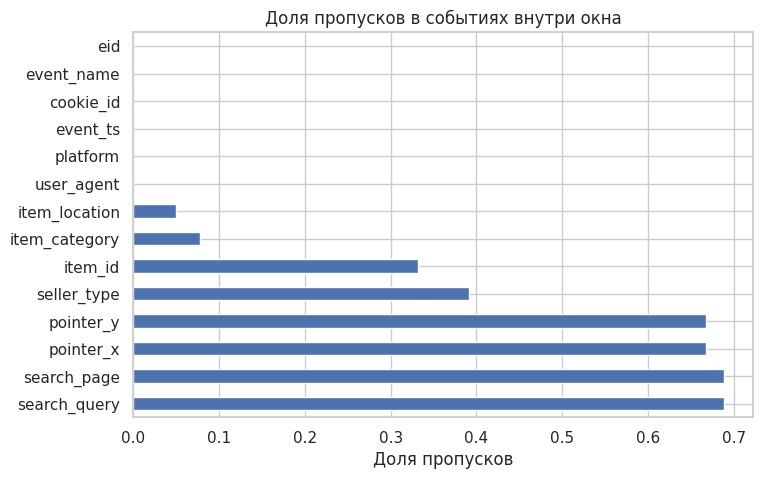

In [136]:
missingness = events_window_eda[events.columns].isna().mean().sort_values(ascending=False)
display(missingness)

missingness.plot(kind="barh", figsize=(8, 5))
plt.title("Доля пропусков в событиях внутри окна")
plt.xlabel("Доля пропусков")
plt.show()

Проверим, для каких типов событий доступны поисковые, товарные и координатные поля

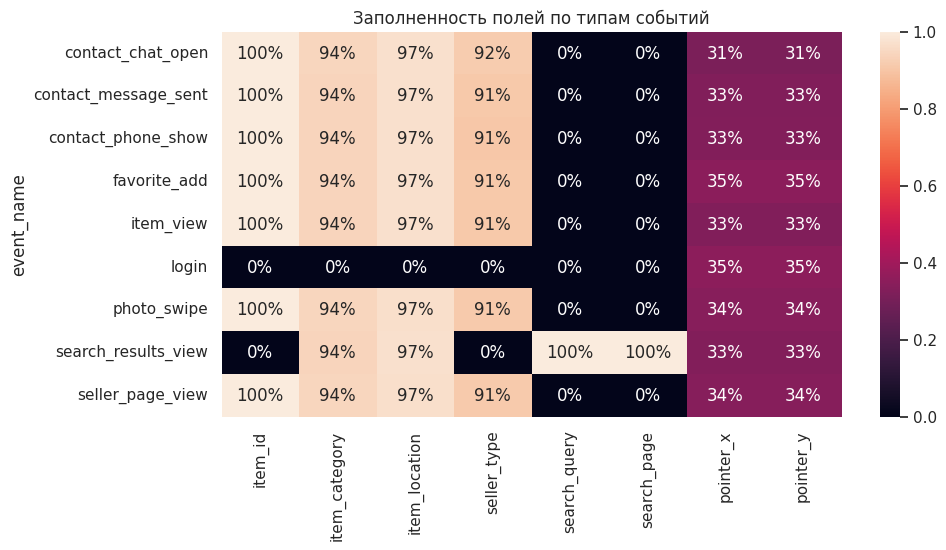

In [137]:
context_columns = [
    "item_id", "item_category", "item_location", "seller_type",
    "search_query", "search_page", "pointer_x", "pointer_y",
]

field_availability = events_window_eda.groupby("event_name")[context_columns].agg(lambda x: x.notna().mean())

plt.figure(figsize=(10, 5))
sns.heatmap(field_availability, annot=True, fmt=".0%")
plt.title("Заполненность полей по типам событий")
plt.show()

Пропуски имеют в основном структурную природу: поисковые поля относятся к просмотрам выдачи, товарные и продавец — к событиям объявлений, а координаты присутствуют только у части событий. Поэтому отсутствие значения само по себе не следует считать ошибкой данных

Изучим частоты типов событий и проверим, несет ли eid дополнительную информацию по сравнению с event_name

,count
event_name,
item_view,108086
search_results_view,89798
photo_swipe,33084
favorite_add,17296
seller_page_view,15542
contact_phone_show,10288
login,5661
contact_chat_open,5548
contact_message_sent,2823


,eid,event_name
1,100,search_results_view
0,200,item_view
6,210,photo_swipe
9,220,seller_page_view
33,300,contact_phone_show
32,301,contact_chat_open
97,303,contact_message_sent
26,400,favorite_add
46,500,login
5,900,captcha_shown


Уникальных eid: 10
Уникальных event_name: 10
Максимум event_name на один eid: 1
Максимум eid на один event_name: 1


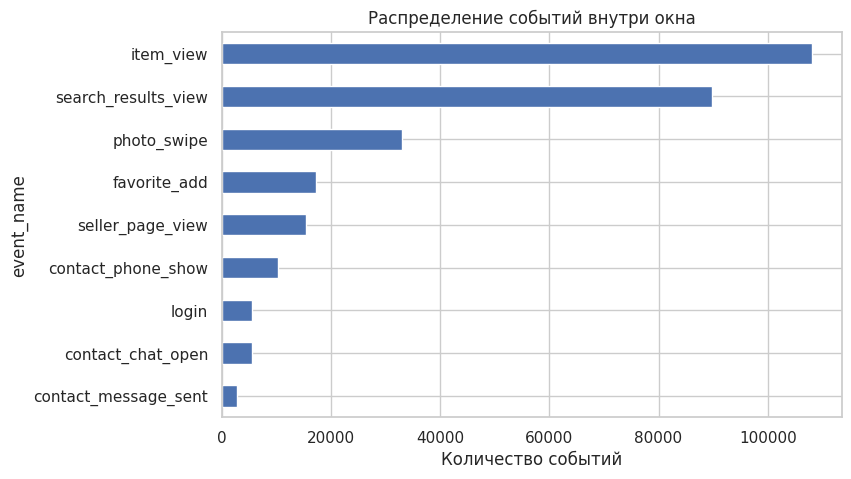

In [138]:
event_counts = events_window_eda["event_name"].value_counts()
eid_event_mapping = events[["eid", "event_name"]].drop_duplicates().sort_values("eid")

display(event_counts)
display(eid_event_mapping)

print("Уникальных eid:", events["eid"].nunique())
print("Уникальных event_name:", events["event_name"].nunique())
print("Максимум event_name на один eid:", eid_event_mapping.groupby("eid")["event_name"].nunique().max())
print("Максимум eid на один event_name:", eid_event_mapping.groupby("event_name")["eid"].nunique().max())

event_counts.sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("Распределение событий внутри окна")
plt.xlabel("Количество событий")
plt.show()

Каждому eid соответствует ровно один event_name и наоборот, поэтому признаки на основе обоих столбцов будут дублировать друг друга. Для дальнейшего анализа достаточно использовать понятные названия событий из event_name

Проверим варианты написания платформы и приведем их к единым семействам

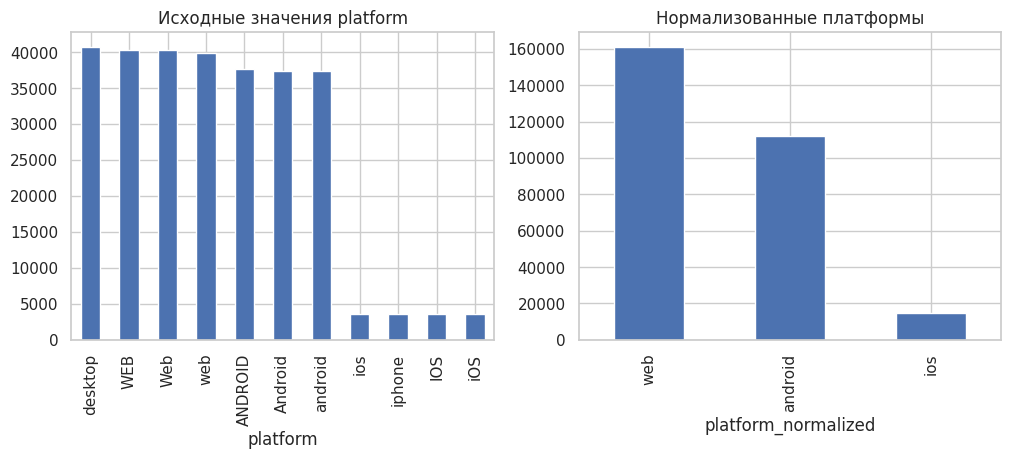

raw_platform_nunique            normalized_platform_nunique           
                    median   mean max                      median   mean max
split                                                                       
test                3.0000 3.2300   4                      1.0000 1.0000   1
train               3.0000 3.2200   4                      1.0000 1.0000   1

In [139]:
events_platform_eda = events_window_eda.copy()
events_platform_eda["platform_normalized"] = events_platform_eda["platform"].str.lower().replace({"iphone": "ios", "desktop": "web"})

raw_platform_counts = events_platform_eda["platform"].value_counts()
normalized_platform_counts = events_platform_eda["platform_normalized"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
raw_platform_counts.plot(kind="bar", ax=axes[0], title="Исходные значения platform")
normalized_platform_counts.plot(kind="bar", ax=axes[1], title="Нормализованные платформы")
plt.show()

platform_diversity = events_platform_eda.groupby(["split", "cookie_id"]).agg(
    raw_platform_nunique=("platform", "nunique"),
    normalized_platform_nunique=("platform_normalized", "nunique"),
).reset_index()

display(platform_diversity.groupby("split")[["raw_platform_nunique", "normalized_platform_nunique"]].agg(["median", "mean", "max"]).round(2))

В platform встречается 11 строковых вариантов из-за регистра и альтернативных названий. После приведения к нижнему регистру и объединения iphone с ios, а desktop с web остаются три содержательных семейства: web, android и ios

Изучим user-agent, проверим покрытие train и test и выделим интерпретируемые технические признаки

In [140]:
train_user_agents = set(events_window_eda.loc[events_window_eda["split"] == "train", "user_agent"])
test_user_agents = set(events_window_eda.loc[events_window_eda["split"] == "test", "user_agent"])

user_agent_checks = {
    "Уникальных User-Agent": events_window_eda["user_agent"].nunique(),
    "Пропусков User-Agent": events_window_eda["user_agent"].isna().sum(),
    "User-Agent только в train": len(train_user_agents - test_user_agents),
    "User-Agent только в test": len(test_user_agents - train_user_agents),
}
display(pd.Series(user_agent_checks, name="Значение"))

cookie_user_agents = events_window_eda.groupby(["split", "cookie_id"])["user_agent"].agg(lambda x: " ".join(x.unique())).reset_index()
cookie_user_agents = cookie_user_agents.merge(meta_eda[["cookie_id", "target"]], on="cookie_id", how="left")
train_cookie_user_agents = cookie_user_agents[cookie_user_agents["split"] == "train"]

ua_patterns = {
    "HeadlessChrome": "HeadlessChrome",
    "Python-клиенты": "python|requests|aiohttp",
    "curl": "curl",
    "okhttp": "okhttp",
    "Mobile": "Mobile",
    "YaBrowser": "YaBrowser",
    "Firefox": "Firefox",
}

ua_rows = []
for name, pattern in ua_patterns.items():
    mask = train_cookie_user_agents["user_agent"].str.contains(pattern, case=False, regex=True, na=False)
    ua_rows.append({
        "Признак User-Agent": name,
        "Количество куки": mask.sum(),
        "Доля ботов": train_cookie_user_agents.loc[mask, "target"].mean(),
    })

ua_summary = pd.DataFrame(ua_rows).sort_values("Доля ботов", ascending=False)
display(ua_summary.round(3))

,Значение
Уникальных User-Agent,148
Пропусков User-Agent,0
User-Agent только в train,0
User-Agent только в test,0


,Признак User-Agent,Количество куки,Доля ботов
0,HeadlessChrome,286,0.2620
2,curl,32,0.2500
1,Python-клиенты,58,0.1900
3,okhttp,1754,0.1030
6,Firefox,1682,0.0830
5,YaBrowser,1459,0.0800
4,Mobile,3033,0.0380


В данных 148 значений User-Agent, пропусков нет, и все варианты встречаются как в train, так и в test. Сырую строку целиком лучше не передавать модели: надежнее извлечь семейство браузера, операционную систему, mobile, headless и признаки технических клиентов

Оценим категориальные поля и появление новых значений в test

In [141]:
train_events_eda = events_window_eda[events_window_eda["split"] == "train"].copy()
test_events_eda = events_window_eda[events_window_eda["split"] == "test"].copy()

categorical_columns = [
    "event_name", "platform", "user_agent", "item_category",
    "item_location", "seller_type", "search_query",
]

cardinality_rows = []
for column in categorical_columns:
    train_values = set(train_events_eda[column].dropna().unique())
    test_values = set(test_events_eda[column].dropna().unique())
    cardinality_rows.append({
        "Признак": column,
        "Уникальных в train": len(train_values),
        "Уникальных в test": len(test_values),
        "Новых значений в test": len(test_values - train_values),
        "Общих значений": len(train_values & test_values),
    })

display(pd.DataFrame(cardinality_rows))

train_items = set(train_events_eda["item_id"].dropna().unique())
test_items = set(test_events_eda["item_id"].dropna().unique())
item_checks = {
    "Уникальных объявлений в train": len(train_items),
    "Уникальных объявлений в test": len(test_items),
    "Общих объявлений": len(train_items & test_items),
    "Новых объявлений в test": len(test_items - train_items),
}
display(pd.Series(item_checks, name="Значение"))

,Признак,Уникальных в train,Уникальных в test,Новых значений в test,Общих значений
0,event_name,9,9,0,9
1,platform,11,11,0,11
2,user_agent,148,148,0,148
3,item_category,15,15,0,15
4,item_location,40,40,0,40
5,seller_type,2,2,0,2
6,search_query,120,120,0,120


,Значение
Уникальных объявлений в train,46953
Уникальных объявлений в test,30902
Общих объявлений,24926
Новых объявлений в test,5976


Перейдем к поведенческим признакам и сравним базовые агрегаты для людей и ботов

,Люди,Боты
n_events,12.0000,20.0000
item_nunique,6.0000,10.0000
location_nunique,5.0000,8.0000
median_gap_seconds,59.0000,25.0000
cookie_age_hours,1482.7800,455.2400


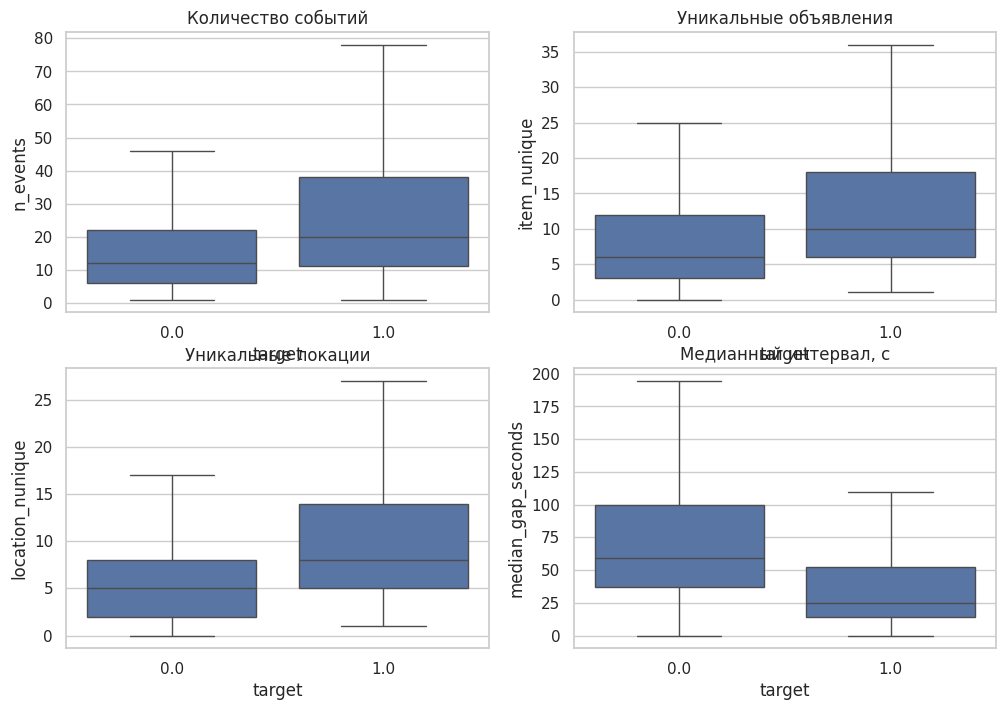

In [142]:
events_sorted_eda = events_window_eda.sort_values(["cookie_id", "event_ts"]).copy()
events_sorted_eda["gap_seconds"] = events_sorted_eda.groupby("cookie_id")["event_ts"].diff().dt.total_seconds()

cookie_behavior = events_sorted_eda.groupby(["split", "cookie_id"]).agg(
    n_events=("event_name", "size"),
    event_type_nunique=("event_name", "nunique"),
    item_nunique=("item_id", "nunique"),
    category_nunique=("item_category", "nunique"),
    location_nunique=("item_location", "nunique"),
    query_nunique=("search_query", "nunique"),
    median_gap_seconds=("gap_seconds", "median"),
    mean_gap_seconds=("gap_seconds", "mean"),
    min_gap_seconds=("gap_seconds", "min"),
).reset_index()

meta_columns = ["cookie_id", "cookie_created_at", "window_start_ts", "target"]
cookie_behavior = cookie_behavior.merge(meta_eda[meta_columns], on="cookie_id", how="left")
cookie_behavior["cookie_age_hours"] = (cookie_behavior["window_start_ts"] - cookie_behavior["cookie_created_at"]).dt.total_seconds() / 3600
train_behavior = cookie_behavior[cookie_behavior["split"] == "train"].copy()

behavior_columns = ["n_events", "item_nunique", "location_nunique", "median_gap_seconds", "cookie_age_hours"]
behavior_medians = train_behavior.groupby("target")[behavior_columns].median().T
behavior_medians.columns = ["Люди", "Боты"]
display(behavior_medians.round(2))

plot_features = {
    "n_events": "Количество событий",
    "item_nunique": "Уникальные объявления",
    "location_nunique": "Уникальные локации",
    "median_gap_seconds": "Медианный интервал, с",
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (feature, title) in zip(axes.flat, plot_features.items()):
    sns.boxplot(data=train_behavior, x="target", y=feature, showfliers=False, ax=ax)
    ax.set_title(title)
plt.show()

У ботов больше событий: медиана равна 20 против 12 у людей. Уникальных объявлений — 10 против 6, уникальных локаций — 8 против 5. Медианный интервал между событиями у ботов составляет 25 секунд, у людей — 59 секунд

Сравним среднее число событий каждого типа на одну куки для двух классов

,Люди,Боты
item_view,6.1600,12.8700
search_results_view,5.1400,10.3600
photo_swipe,2.0700,2.0700
seller_page_view,0.9000,1.7400
favorite_add,1.1100,0.8000
contact_phone_show,0.6200,0.7600
contact_chat_open,0.3300,0.4200
contact_message_sent,0.1700,0.2300
login,0.3600,0.2300


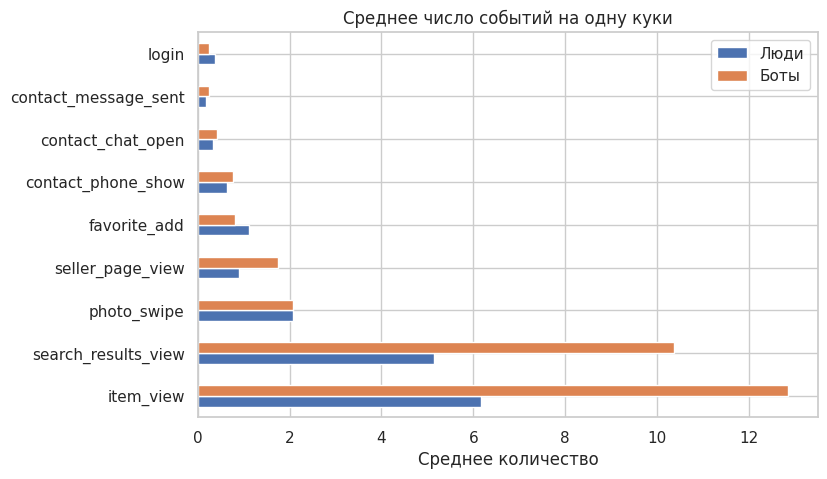

In [143]:
event_counts_by_cookie = pd.crosstab(train_events_eda["cookie_id"], train_events_eda["event_name"])
event_counts_by_cookie = event_counts_by_cookie.reindex(train["cookie_id"], fill_value=0).reset_index()
event_counts_by_cookie = event_counts_by_cookie.merge(train[["cookie_id", "target"]], on="cookie_id", how="left")

event_type_comparison = event_counts_by_cookie.groupby("target").mean(numeric_only=True).T
event_type_comparison.columns = ["Люди", "Боты"]
event_type_comparison = event_type_comparison.sort_values("Боты", ascending=False)
display(event_type_comparison.round(2))

event_type_comparison.plot(kind="barh", figsize=(8, 5))
plt.title("Среднее число событий на одну куки")
plt.xlabel("Среднее количество")
plt.show()

Боты примерно вдвое чаще просматривают объявления и поисковые выдачи, а также чаще переходят на страницу продавца. Входы в аккаунт и добавления в избранное, напротив, относительно менее характерны для автоматизированного трафика

Отдельно проверим связь возраста cookie с целевой переменной

,Возраст cookie,Количество куки,Количество ботов,Доля ботов
0,Меньше 20 часов,1112,197.0000,0.1770
1,20–56 часов,1099,174.0000,0.1580
2,56 часов – 7 дней,421,62.0000,0.1470
3,7–30 дней,939,47.0000,0.0500
4,Больше 30 дней,7520,419.0000,0.0560


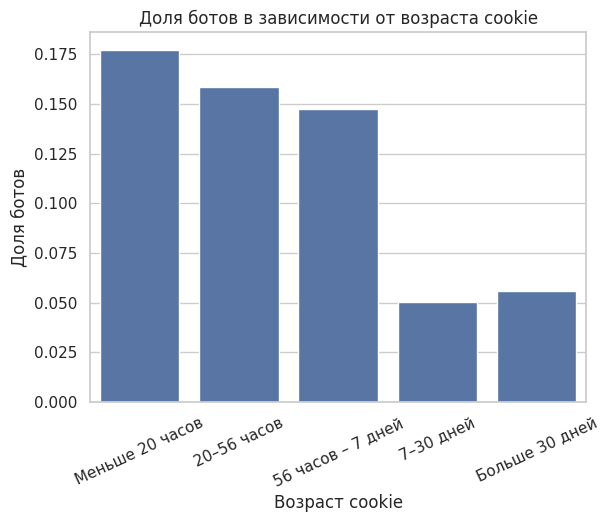

In [144]:
age_bins = [-np.inf, 20, 56, 24 * 7, 24 * 30, np.inf]
age_labels = ["Меньше 20 часов", "20–56 часов", "56 часов – 7 дней", "7–30 дней", "Больше 30 дней"]
train_behavior["cookie_age_group"] = pd.cut(train_behavior["cookie_age_hours"], bins=age_bins, labels=age_labels, right=False)

age_target_summary = train_behavior.groupby("cookie_age_group", observed=False)["target"].agg(["count", "sum", "mean"]).reset_index()
age_target_summary.columns = ["Возраст cookie", "Количество куки", "Количество ботов", "Доля ботов"]
display(age_target_summary.round(3))

sns.barplot(data=age_target_summary, x="Возраст cookie", y="Доля ботов")
plt.title("Доля ботов в зависимости от возраста cookie")
plt.xticks(rotation=25)
plt.show()

Возраст cookie связан с целевой переменной. Среди куки младше 20 часов доля ботов составляет 17,7%, в группах до семи дней — около 15%, а после семи дней снижается примерно до 5–6%. В модели будем использовать численный возраст без жестких правил

Сопоставим распределения основных поведенческих показателей и типов событий между train и test

split                          test     train
n_events           median   12.0000   12.0000
                   mean     18.2700   17.8900
item_nunique       median    6.0000    6.0000
                   mean      9.4900    9.3100
location_nunique   median    5.0000    5.0000
                   mean      6.3500    6.2000
query_nunique      median    3.0000    3.0000
                   mean      3.9300    3.8700
median_gap_seconds median   55.0000   56.0000
                   mean    199.6500  209.4800
cookie_age_hours   median 1407.1500 1434.2200
                   mean   1719.5300 1724.8100

split,test,train,Абсолютное изменение
event_name,,,
photo_swipe,0.1130,0.1157,0.0027
search_results_view,0.3131,0.3110,0.0021
favorite_add,0.0586,0.0607,0.0020
item_view,0.3763,0.3746,0.0017
contact_chat_open,0.0197,0.0190,0.0007
contact_phone_show,0.0361,0.0355,0.0006
contact_message_sent,0.0094,0.0100,0.0006
seller_page_view,0.0541,0.0539,0.0003
login,0.0196,0.0197,0.0000


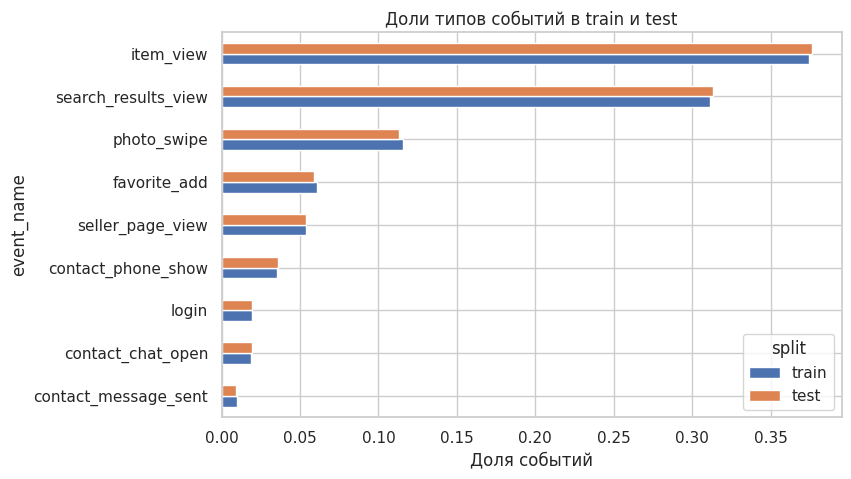

In [145]:
drift_features = ["n_events", "item_nunique", "location_nunique", "query_nunique", "median_gap_seconds", "cookie_age_hours"]
cookie_drift_summary = cookie_behavior.groupby("split")[drift_features].agg(["median", "mean"]).T
display(cookie_drift_summary.round(2))

event_share_by_split = pd.crosstab(events_window_eda["event_name"], events_window_eda["split"], normalize="columns")
event_share_by_split["Абсолютное изменение"] = (event_share_by_split["test"] - event_share_by_split["train"]).abs()
event_share_by_split = event_share_by_split.sort_values("Абсолютное изменение", ascending=False)
display(event_share_by_split.round(4))

event_share_by_split[["train", "test"]].sort_values("train").plot(kind="barh", figsize=(8, 5))
plt.title("Доли типов событий в train и test")
plt.xlabel("Доля событий")
plt.show()

Распределения основных агрегатов и доли типов событий в train и test близки, однако выборки относятся к разным последовательным периодам. Поэтому качество будем оценивать на последних датах train, имитируя реальное применение модели к будущим данным

Основные выводы EDA:

- В train находится 11 091 кука, из них 899 относятся к ботам. В test находится 4 909 куки. Выборки не пересекаются по cookie_id, а у каждой куки есть события внутри окна
- Все окна наблюдения имеют длину 24 часа. Train охватывает 6–19 апреля 2026 года, test — 20–26 апреля, поэтому для валидации нужен временной split
- Из 328 905 событий в окно попадают 288 126. Все 7 928 событий captcha_shown находятся вне окна, поэтому использовать капчу как признак нельзя
- Перед расчетом временных признаков события нужно сортировать по cookie_id и event_ts. Точные дубликаты удалим, оставив только по одному повторению каждого события
- Пропуски в основном связаны с типом события. eid дублирует event_name, platform нужно нормализовать, а из User-Agent лучше извлечь отдельные понятные признаки
- Основные поведенческие сигналы — количество событий, число уникальных объявлений и локаций, интервалы между действиями, типы событий и возраст cookie

# 3. Предобработка событий

Объединим данные train и test, чтобы одинаково обрабатывать события из обеих выборок

In [146]:
train_meta = train.assign(split="train")
test_meta = test.assign(split="test", target=np.nan)
meta = pd.concat([train_meta, test_meta], ignore_index=True)

print(meta.shape)
display(meta.groupby("split").size())

(16000, 6)


,0
split,
test,4909
train,11091


Присоединим к событиям границы окна и оставим только данные, доступные к моменту окончания наблюдения

In [147]:
event_columns = events.columns.tolist()
event_meta_columns = ["cookie_id", "window_start_ts", "window_end_ts", "split"]
events_processed = events.merge(meta[event_meta_columns], on="cookie_id", how="inner")
events_processed = events_processed[(events_processed["event_ts"] >= events_processed["window_start_ts"]) & (events_processed["event_ts"] < events_processed["window_end_ts"])].copy()

print("Событий после фильтрации:", len(events_processed))
display(events_processed.groupby("split").size())

Событий после фильтрации: 288126


,0
split,
test,89690
train,198436


Удалим точные дубликаты, оставив только первое повторение каждого события, затем отсортируем события по cookie_id и event_ts

In [148]:
n_events_before_dedup = len(events_processed)
events_processed = events_processed.drop_duplicates(subset=event_columns, keep="first")
events_processed = events_processed.sort_values(["cookie_id", "event_ts"], kind="mergesort").reset_index(drop=True)

print("Удалено дубликатов:", n_events_before_dedup - len(events_processed))
print("Событий после удаления дубликатов:", len(events_processed))

Удалено дубликатов: 4293
Событий после удаления дубликатов: 283833


Приведем platform к трем основным группам и выделим из User-Agent понятные признаки браузера, операционной системы и технического клиента

In [149]:
events_processed["platform_normalized"] = events_processed["platform"].str.lower().replace({"desktop": "web", "iphone": "ios"})

ua = events_processed["user_agent"].str.lower()
events_processed["ua_is_mobile"] = ua.str.contains("mobile|android|iphone|ipad", regex=True).astype("int8")
events_processed["ua_is_headless"] = ua.str.contains("headless", regex=False).astype("int8")
events_processed["ua_is_technical"] = ua.str.contains("headless|python|requests|aiohttp|curl|okhttp", regex=True).astype("int8")

browser_conditions = [
    ua.str.contains("headless", regex=False),
    ua.str.contains("python|requests|aiohttp", regex=True),
    ua.str.contains("curl", regex=False),
    ua.str.contains("okhttp", regex=False),
    ua.str.contains("edg/", regex=False),
    ua.str.contains("yabrowser", regex=False),
    ua.str.contains("firefox", regex=False),
    ua.str.contains("chrome", regex=False),
    ua.str.contains("safari", regex=False),
]
browser_names = ["headless", "python", "curl", "okhttp", "edge", "yandex", "firefox", "chrome", "safari"]
events_processed["browser_family"] = np.select(browser_conditions, browser_names, default="other")

os_conditions = [
    ua.str.contains("android", regex=False),
    ua.str.contains("iphone|ipad", regex=True),
    ua.str.contains("windows", regex=False),
    ua.str.contains("macintosh|mac os", regex=True),
    ua.str.contains("linux", regex=False),
]
os_names = ["android", "ios", "windows", "macos", "linux"]
events_processed["os_family"] = np.select(os_conditions, os_names, default="other")

display(events_processed[["platform_normalized", "browser_family", "os_family", "ua_is_mobile", "ua_is_headless", "ua_is_technical"]].head())

,platform_normalized,browser_family,os_family,ua_is_mobile,ua_is_headless,ua_is_technical
0,android,chrome,android,1,0,0
1,android,chrome,android,1,0,0
2,android,chrome,android,1,0,0
3,android,chrome,android,1,0,0
4,android,chrome,android,1,0,0


Проверим размер итоговых таблиц, наличие всех куки и правильный порядок событий

In [150]:
events_are_sorted = events_processed.groupby("cookie_id")["event_ts"].apply(lambda x: x.is_monotonic_increasing).all()

preprocessing_checks = pd.Series({
    "Событий после удаления дубликатов": len(events_processed),
    "Полных дубликатов": events_processed.duplicated(subset=event_columns).sum(),
    "Куки после фильтрации": events_processed["cookie_id"].nunique(),
    "Пропусков в нормализованной платформе": events_processed["platform_normalized"].isna().sum(),
    "События отсортированы": events_are_sorted,
})

display(preprocessing_checks)

,0
Событий после удаления дубликатов,283833
Полных дубликатов,0
Куки после фильтрации,16000
Пропусков в нормализованной платформе,0
События отсортированы,True


После удаления дубликатов в events_processed осталось 283 833 события. Эту таблицу будем использовать для всех дальнейших расчетов

# 4. Построение признаков

Начнем с признаков из метаданных куки: возраста на начало окна и времени создания

In [151]:
features = meta[["cookie_id", "split", "target", "window_start_ts"]].copy()
features["cookie_age_hours"] = (meta["window_start_ts"] - meta["cookie_created_at"]).dt.total_seconds() / 3600
features["cookie_created_hour"] = meta["cookie_created_at"].dt.hour
features["cookie_created_weekday"] = meta["cookie_created_at"].dt.weekday

display(features.head())

,cookie_id,split,target,window_start_ts,cookie_age_hours,cookie_created_hour,cookie_created_weekday
0,ck_54a059eb7d3ea68b,train,0.0000,2026-04-06,3254.4886,9,4
1,ck_7e4de46eeab82974,train,0.0000,2026-04-06,4669.8267,10,1
2,ck_9320229ef6304522,train,0.0000,2026-04-06,791.8661,0,2
3,ck_30ccd25bc1714ed9,train,0.0000,2026-04-06,13.1222,10,6
4,ck_a77c5f05948cdeef,train,0.0000,2026-04-06,2276.0903,3,3


Посчитаем количество событий и разнообразие объявлений, категорий, локаций, запросов и технических параметров

In [152]:
event_features = events_processed.groupby("cookie_id").agg(
    n_events=("event_name", "size"),
    event_type_nunique=("event_name", "nunique"),
    item_event_count=("item_id", "count"),
    item_nunique=("item_id", "nunique"),
    category_nunique=("item_category", "nunique"),
    location_nunique=("item_location", "nunique"),
    query_event_count=("search_query", "count"),
    query_nunique=("search_query", "nunique"),
    search_page_nunique=("search_page", "nunique"),
    seller_type_nunique=("seller_type", "nunique"),
    user_agent_nunique=("user_agent", "nunique"),
    platform_nunique=("platform_normalized", "nunique"),
    browser_nunique=("browser_family", "nunique"),
    os_nunique=("os_family", "nunique"),
).reset_index()

features = features.merge(event_features, on="cookie_id", how="left")
display(event_features.head())

,cookie_id,n_events,event_type_nunique,item_event_count,item_nunique,category_nunique,location_nunique,query_event_count,query_nunique,search_page_nunique,seller_type_nunique,user_agent_nunique,platform_nunique,browser_nunique,os_nunique
0,ck_00013fdfa0bd37dd,15,6,10,9,3,4,3,3,3,2,1,1,1,1
1,ck_000c95f1408dcb00,16,4,13,9,2,8,3,3,3,2,1,1,1,1
2,ck_000e8c52636e3bec,34,7,24,20,4,12,9,8,6,2,1,1,1,1
3,ck_0010e31baa4a1fb7,16,6,11,8,3,4,4,4,1,2,1,1,1,1
4,ck_0010ec3874fb5378,74,6,53,31,2,19,20,8,4,2,1,1,1,1


Для каждого типа события добавим количество и долю среди всех действий куки

In [153]:
event_counts = pd.crosstab(events_processed["cookie_id"], events_processed["event_name"])
event_shares = event_counts.div(event_counts.sum(axis=1), axis=0)

event_counts = event_counts.add_prefix("event_count_").reset_index()
event_shares = event_shares.add_prefix("event_share_").reset_index()

features = features.merge(event_counts, on="cookie_id", how="left")
features = features.merge(event_shares, on="cookie_id", how="left")

print("Добавлено признаков по типам событий:", len(event_counts.columns) + len(event_shares.columns) - 2)

Добавлено признаков по типам событий: 18


Добавим временные признаки: длительность активности, число активных часов и минут, интервалы между соседними событиями и повторяющиеся действия

In [154]:
events_for_features = events_processed.copy()
events_for_features["gap_seconds"] = events_for_features.groupby("cookie_id")["event_ts"].diff().dt.total_seconds()
events_for_features["event_hour"] = events_for_features["event_ts"].dt.hour
events_for_features["event_minute"] = events_for_features["event_ts"].dt.floor("min")

previous_event = events_for_features.groupby("cookie_id")["event_name"].shift()
previous_item = events_for_features.groupby("cookie_id")["item_id"].shift()
events_for_features["same_event_as_previous"] = events_for_features["event_name"].eq(previous_event).astype("int8")
events_for_features["same_item_as_previous"] = (events_for_features["item_id"].notna() & events_for_features["item_id"].eq(previous_item)).astype("int8")

time_features = events_for_features.groupby("cookie_id").agg(
    first_event_ts=("event_ts", "min"),
    last_event_ts=("event_ts", "max"),
    active_hours=("event_hour", "nunique"),
    active_minutes=("event_minute", "nunique"),
    same_event_share=("same_event_as_previous", "mean"),
    same_item_share=("same_item_as_previous", "mean"),
).reset_index()

window_start = meta.set_index("cookie_id")["window_start_ts"]
time_features = time_features.set_index("cookie_id")
time_features["activity_duration_seconds"] = (time_features["last_event_ts"] - time_features["first_event_ts"]).dt.total_seconds()
time_features["first_event_offset_seconds"] = (time_features["first_event_ts"] - window_start).dt.total_seconds()
time_features["last_event_offset_seconds"] = (time_features["last_event_ts"] - window_start).dt.total_seconds()
time_features = time_features.drop(columns=["first_event_ts", "last_event_ts"]).reset_index()

gaps = events_for_features.dropna(subset=["gap_seconds"]).copy()
gaps["gap_lt_1s"] = gaps["gap_seconds"].lt(1)
gaps["gap_lt_5s"] = gaps["gap_seconds"].lt(5)
gaps["gap_lt_30s"] = gaps["gap_seconds"].lt(30)

gap_features = gaps.groupby("cookie_id").agg(
    gap_mean_seconds=("gap_seconds", "mean"),
    gap_median_seconds=("gap_seconds", "median"),
    gap_min_seconds=("gap_seconds", "min"),
    gap_max_seconds=("gap_seconds", "max"),
    gap_std_seconds=("gap_seconds", "std"),
    gap_lt_1s_share=("gap_lt_1s", "mean"),
    gap_lt_5s_share=("gap_lt_5s", "mean"),
    gap_lt_30s_share=("gap_lt_30s", "mean"),
).reset_index()

features = features.merge(time_features, on="cookie_id", how="left")
features = features.merge(gap_features, on="cookie_id", how="left")

print("Добавлено временных признаков:", len(time_features.columns) + len(gap_features.columns) - 2)

Добавлено временных признаков: 15


На основе счетчиков рассчитаем интенсивность активности и долю повторных объявлений и запросов

In [155]:
features["events_per_active_minute"] = features["n_events"] / features["active_minutes"].clip(lower=1)
features["events_per_item"] = features["n_events"] / features["item_nunique"].clip(lower=1)
features["items_per_category"] = features["item_nunique"] / features["category_nunique"].clip(lower=1)
features["item_repeat_share"] = (1 - features["item_nunique"] / features["item_event_count"].clip(lower=1)).where(features["item_event_count"] > 0, 0)
features["query_repeat_share"] = (1 - features["query_nunique"] / features["query_event_count"].clip(lower=1)).where(features["query_event_count"] > 0, 0)

ratio_columns = ["events_per_active_minute", "events_per_item", "items_per_category", "item_repeat_share", "query_repeat_share"]
display(features[ratio_columns].head())

,events_per_active_minute,events_per_item,items_per_category,item_repeat_share,query_repeat_share
0,1.7500,1.7500,1.3333,0.0000,0.0000
1,1.3667,2.1579,19.0000,0.4062,0.3750
2,1.7143,1.8947,2.7143,0.0500,0.2308
3,1.3125,2.1000,10.0000,0.4444,0.0000
4,1.1200,1.7500,4.0000,0.2727,0.0000


Добавим доли мобильных, headless и технических клиентов, наличие координат, характеристики поисковых страниц и основные категории устройств

In [156]:
events_for_features["has_pointer"] = (events_for_features["pointer_x"].notna() & events_for_features["pointer_y"].notna()).astype("int8")

def most_common(values):
    return values.mode().iat[0]

technical_features = events_for_features.groupby("cookie_id").agg(
    mobile_share=("ua_is_mobile", "mean"),
    headless_share=("ua_is_headless", "mean"),
    technical_client_share=("ua_is_technical", "mean"),
    pointer_share=("has_pointer", "mean"),
    search_page_mean=("search_page", "mean"),
    search_page_max=("search_page", "max"),
    search_page_std=("search_page", "std"),
    pointer_x_std=("pointer_x", "std"),
    pointer_y_std=("pointer_y", "std"),
    main_platform=("platform_normalized", most_common),
    main_browser=("browser_family", most_common),
    main_os=("os_family", most_common),
).reset_index()

platform_shares = pd.crosstab(events_for_features["cookie_id"], events_for_features["platform_normalized"], normalize="index")
platform_shares = platform_shares.add_prefix("platform_share_").reset_index()

features = features.merge(technical_features, on="cookie_id", how="left")
features = features.merge(platform_shares, on="cookie_id", how="left")

display(technical_features.head())

,cookie_id,mobile_share,headless_share,technical_client_share,pointer_share,search_page_mean,search_page_max,search_page_std,pointer_x_std,pointer_y_std,main_platform,main_browser,main_os
0,ck_00013fdfa0bd37dd,1.0000,0.0000,0.0000,0.0000,2.0000,3.0000,1.0000,NaN,NaN,android,chrome,android
1,ck_000c95f1408dcb00,0.0000,0.0000,0.0000,1.0000,2.3333,4.0000,1.5275,494.9809,338.0746,web,chrome,macos
2,ck_000e8c52636e3bec,0.0000,0.0000,0.0000,0.9118,3.7778,12.0000,3.5277,561.5441,277.7194,web,firefox,windows
3,ck_0010e31baa4a1fb7,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,501.8909,361.4342,web,yandex,windows
4,ck_0010ec3874fb5378,0.0000,0.0000,0.0000,0.0000,1.8000,6.0000,1.1965,NaN,NaN,web,yandex,windows


Объединим все признаки, заполним пропуски и подготовим отдельные таблицы для train и test

In [157]:
categorical_features = ["main_platform", "main_browser", "main_os"]

numeric_feature_columns = features.select_dtypes(include=np.number).columns.drop("target")
features[numeric_feature_columns] = features[numeric_feature_columns].replace([np.inf, -np.inf], np.nan).fillna(0)
features[categorical_features] = features[categorical_features].fillna("unknown")

feature_columns = [column for column in features.columns if column not in ["cookie_id", "split", "target", "window_start_ts"]]

train_features = train[["cookie_id", "target", "window_start_ts"]].merge(features[["cookie_id"] + feature_columns], on="cookie_id", how="left")
test_features = test[["cookie_id", "window_start_ts"]].merge(features[["cookie_id"] + feature_columns], on="cookie_id", how="left")

assert len(train_features) == len(train)
assert len(test_features) == len(test)
assert train_features["cookie_id"].is_unique
assert test_features["cookie_id"].is_unique
assert train_features["cookie_id"].equals(train["cookie_id"])
assert test_features["cookie_id"].equals(test["cookie_id"])
assert sample_submission["cookie_id"].is_unique
assert set(sample_submission["cookie_id"]) == set(test["cookie_id"])

print("train_features:", train_features.shape)
print("test_features:", test_features.shape)
print("Признаков:", len(feature_columns))
print("Пропусков:", train_features[feature_columns].isna().sum().sum() + test_features[feature_columns].isna().sum().sum())

train_features: (11091, 73)
test_features: (4909, 72)
Признаков: 70
Пропусков: 0


В итоговые таблицы вошли 70 признаков: возраст cookie, количество и доли событий, разнообразие объявлений и запросов, интервалы между действиями, интенсивность активности, платформа и характеристики User-Agent

window_start_ts сохраним только для временного разделения выборки и не будем передавать модели

# 5. Временная валидация и метрика

Разделим train по времени: данные за 6–16 апреля используем для обучения, а последние три дня с 17 по 19 апреля — для валидации

In [158]:
VALIDATION_START = pd.Timestamp("2026-04-17")
validation_mask = train_features["window_start_ts"] >= VALIDATION_START

X_train = train_features.loc[~validation_mask, feature_columns].reset_index(drop=True)
y_train = train_features.loc[~validation_mask, "target"].reset_index(drop=True)
X_valid = train_features.loc[validation_mask, feature_columns].reset_index(drop=True)
y_valid = train_features.loc[validation_mask, "target"].reset_index(drop=True)

train_dates = train_features.loc[~validation_mask, "window_start_ts"]
valid_dates = train_features.loc[validation_mask, "window_start_ts"]

assert train_dates.max() < valid_dates.min()

Основную метрику считаем официальной функцией из metric.py: она выбирает максимальный Precision среди порогов, при которых Recall не ниже 70%

Дополнительно будем смотреть PR-AUC и ROC-AUC, но выбирать модель по основной метрике

In [159]:
def calculate_metrics(y_true, scores):
    return pd.Series({
        "Precision при Recall >= 70%": precision_at_recall(y_true, scores),
        "PR-AUC": average_precision_score(y_true, scores),
        "ROC-AUC": roc_auc_score(y_true, scores),
    })

constant_scores = np.full(len(y_valid), y_train.mean())
constant_metrics = calculate_metrics(y_valid, constant_scores)

display(constant_metrics.to_frame(name="Константный прогноз"))

,Константный прогноз
Precision при Recall >= 70%,0.0820
PR-AUC,0.0820
ROC-AUC,0.5000


В обучающей части находится 9 140 куки, в валидационной — 1 951. Доля ботов почти одинакова: 8,09% и 8,20%

Константный прогноз дает Precision 0,082 при Recall не ниже 70%. Результаты Random Forest и CatBoost будем сравнивать с этим уровнем

# 6. Бейзлайн Random Forest

Random Forest не умеет работать со строковыми категориями напрямую, поэтому преобразуем платформу, браузер и операционную систему в отдельные бинарные признаки

In [160]:
X_train_rf = pd.get_dummies(X_train, columns=categorical_features, dtype="int8")
X_valid_rf = pd.get_dummies(X_valid, columns=categorical_features, dtype="int8")
X_valid_rf = X_valid_rf.reindex(columns=X_train_rf.columns, fill_value=0)
rf_feature_columns = X_train_rf.columns.tolist()

print("X_train_rf:", X_train_rf.shape)
print("X_valid_rf:", X_valid_rf.shape)

X_train_rf: (9140, 85)
X_valid_rf: (1951, 85)


Обучим Random Forest без подбора гиперпараметров. Для устойчивости используем 500 деревьев, а дисбаланс классов учтем через class_weight

In [161]:
random_forest_model = RandomForestClassifier(
    n_estimators=500,
    min_samples_leaf=3,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

random_forest_model.fit(X_train_rf, y_train)
rf_valid_scores = random_forest_model.predict_proba(X_valid_rf)[:, 1]
rf_metrics = calculate_metrics(y_valid, rf_valid_scores)

model_comparison = pd.concat([constant_metrics, rf_metrics], axis=1)
model_comparison.columns = ["Константный прогноз", "Random Forest"]
display(model_comparison)

,Константный прогноз,Random Forest
Precision при Recall >= 70%,0.0820,0.7044
PR-AUC,0.0820,0.7348
ROC-AUC,0.5000,0.9147


Посмотрим, какие признаки дали наибольший вклад в решение Random Forest

,Важность
pointer_x_std,0.0753
gap_median_seconds,0.0668
events_per_active_minute,0.0665
gap_lt_30s_share,0.0661
items_per_category,0.0419
search_page_mean,0.0303
gap_min_seconds,0.0300
location_nunique,0.0288
cookie_age_hours,0.0282
pointer_y_std,0.0254


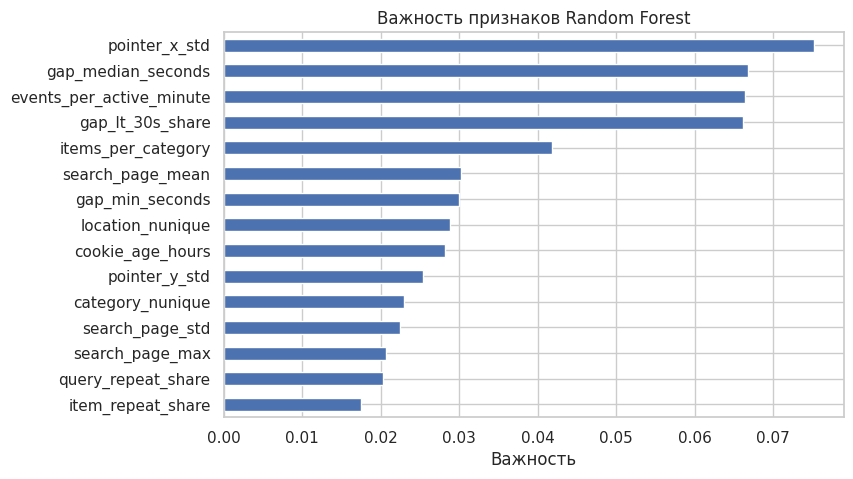

In [162]:
rf_feature_importance = pd.Series(random_forest_model.feature_importances_, index=rf_feature_columns)
rf_feature_importance = rf_feature_importance.sort_values(ascending=False).head(15)

display(rf_feature_importance.to_frame(name="Важность"))

rf_feature_importance.sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("Важность признаков Random Forest")
plt.xlabel("Важность")
plt.show()

Random Forest заметно превзошел константный прогноз: Precision при Recall не ниже 70% вырос с 0,082 до 0,696, PR-AUC составил 0,738, ROC-AUC — 0,911

Наибольший вклад дали разброс координат, интенсивность событий, медианный интервал между действиями, доля коротких интервалов и разнообразие объявлений. Этот результат будем использовать как бейзлайн для сравнения с CatBoost

# 7. CatBoost и подбор гиперпараметров

CatBoost умеет работать с категориальными признаками напрямую, поэтому используем исходные main_platform, main_browser и main_os без one-hot encoding

In [163]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.enqueue_trial({
    "depth": 5,
    "learning_rate": 0.03,
    "l2_leaf_reg": 8,
    "random_strength": 1,
    "bagging_temperature": 1,
})

N_TRIALS = 20
print("Количество попыток:", N_TRIALS)

Количество попыток: 20


Подберем параметры CatBoost с помощью Optuna. Проведем 20 попыток на временной валидации, в каждой используем early stopping и максимизируем Precision при Recall не ниже 70%

In [164]:
def objective(trial):
    params = {
        "depth": trial.suggest_int("depth", 4, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.15, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 2, 12),
        "random_strength": trial.suggest_float("random_strength", 0.001, 5, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 5),
    }

    model = CatBoostClassifier(
        iterations=600,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=RANDOM_STATE,
        allow_writing_files=False,
        verbose=False,
        **params,
    )

    model.fit(
        X_train,
        y_train,
        cat_features=categorical_features,
        eval_set=(X_valid, y_valid),
        early_stopping_rounds=70,
        verbose=False,
    )

    valid_scores = model.predict_proba(X_valid)[:, 1]
    metrics = calculate_metrics(y_valid, valid_scores)

    trial.set_user_attr("best_iteration", model.get_best_iteration() + 1)
    trial.set_user_attr("pr_auc", metrics["PR-AUC"])
    trial.set_user_attr("roc_auc", metrics["ROC-AUC"])

    return metrics["Precision при Recall >= 70%"]

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

optuna_results = study.trials_dataframe()
optuna_results = optuna_results.sort_values("value", ascending=False).reset_index(drop=True)
display(optuna_results.head(10))

  0%|          | 0/20 [00:00<?, ?it/s]

,number,value,datetime_start,datetime_complete,duration,params_bagging_temperature,params_depth,params_l2_leaf_reg,params_learning_rate,params_random_strength,user_attrs_best_iteration,user_attrs_pr_auc,user_attrs_roc_auc,system_attrs_fixed_params,state
0,14,0.7740,2026-09-28 20:39:06.176103,2026-09-28 20:39:13.798448,0 days 00:00:07.622345,1.7382,7,8.9475,0.0984,0.0104,115,0.7633,0.9257,NaN,COMPLETE
1,6,0.7703,2026-09-28 20:37:42.884851,2026-09-28 20:37:58.053023,0 days 00:00:15.168172,0.2323,7,7.1423,0.0299,0.1554,285,0.7610,0.9255,NaN,COMPLETE
2,1,0.7671,2026-09-28 20:36:51.308991,2026-09-28 20:36:56.095039,0 days 00:00:04.786048,0.7801,5,9.3199,0.1358,0.1638,159,0.7660,0.9254,NaN,COMPLETE
3,10,0.7635,2026-09-28 20:38:36.946570,2026-09-28 20:38:47.893517,0 days 00:00:10.946947,0.0726,8,5.1946,0.0819,0.0012,107,0.7575,0.9246,NaN,COMPLETE
4,11,0.7568,2026-09-28 20:38:47.895380,2026-09-28 20:38:53.414140,0 days 00:00:05.518760,0.0207,6,9.1254,0.1421,0.2084,126,0.7612,0.9199,NaN,COMPLETE
5,18,0.7451,2026-09-28 20:39:43.242368,2026-09-28 20:39:53.322046,0 days 00:00:10.079678,4.1024,8,6.5996,0.0938,0.0036,100,0.7610,0.9206,NaN,COMPLETE
6,9,0.7386,2026-09-28 20:38:28.784188,2026-09-28 20:38:36.945086,0 days 00:00:08.160898,1.2939,4,2.3439,0.0542,2.3097,338,0.7636,0.9253,NaN,COMPLETE
7,5,0.7368,2026-09-28 20:37:20.928936,2026-09-28 20:37:42.882390,0 days 00:00:21.953454,2.2803,7,4.9214,0.0265,0.0227,455,0.7599,0.9246,NaN,COMPLETE
8,3,0.7355,2026-09-28 20:37:07.793446,2026-09-28 20:37:12.501494,0 days 00:00:04.708048,0.9091,4,10.3244,0.1412,0.0061,196,0.7607,0.9226,NaN,COMPLETE
9,17,0.7320,2026-09-28 20:39:29.464083,2026-09-28 20:39:43.240626,0 days 00:00:13.776543,2.7334,7,4.1364,0.0205,0.0014,266,0.7532,0.9246,NaN,COMPLETE


Выберем лучшую комбинацию по основной метрике и сравним CatBoost с бейзлайном

In [165]:
best_params = study.best_params
best_iteration = int(study.best_trial.user_attrs["best_iteration"])

best_catboost_model = CatBoostClassifier(
    iterations=best_iteration,
    loss_function="Logloss",
    random_seed=RANDOM_STATE,
    allow_writing_files=False,
    verbose=False,
    **best_params,
)

best_catboost_model.fit(X_train, y_train, cat_features=categorical_features, verbose=False)
best_catboost_scores = best_catboost_model.predict_proba(X_valid)[:, 1]
best_catboost_metrics = calculate_metrics(y_valid, best_catboost_scores)

model_comparison = pd.concat([constant_metrics, rf_metrics, best_catboost_metrics], axis=1)
model_comparison.columns = ["Константный прогноз", "Random Forest", "CatBoost"]
display(model_comparison)

print("Лучшие параметры:", best_params)
print("Количество итераций:", best_iteration)

,Константный прогноз,Random Forest,CatBoost
Precision при Recall >= 70%,0.0820,0.7044,0.7308
PR-AUC,0.0820,0.7348,0.7550
ROC-AUC,0.5000,0.9147,0.9186


Лучшие параметры: {'depth': 7, 'learning_rate': 0.09841465364653953, 'l2_leaf_reg': 8.947539412449062, 'random_strength': 0.0103588533021809, 'bagging_temperature': 1.7381671524829134}
Количество итераций: 115


Посмотрим на наиболее важные признаки лучшей модели

,Важность
pointer_x_std,14.8916
location_nunique,7.2832
category_nunique,6.1194
gap_median_seconds,5.9986
items_per_category,5.4983
gap_min_seconds,4.6201
item_repeat_share,4.5891
events_per_active_minute,4.1694
search_page_mean,3.9743
gap_lt_30s_share,3.2948


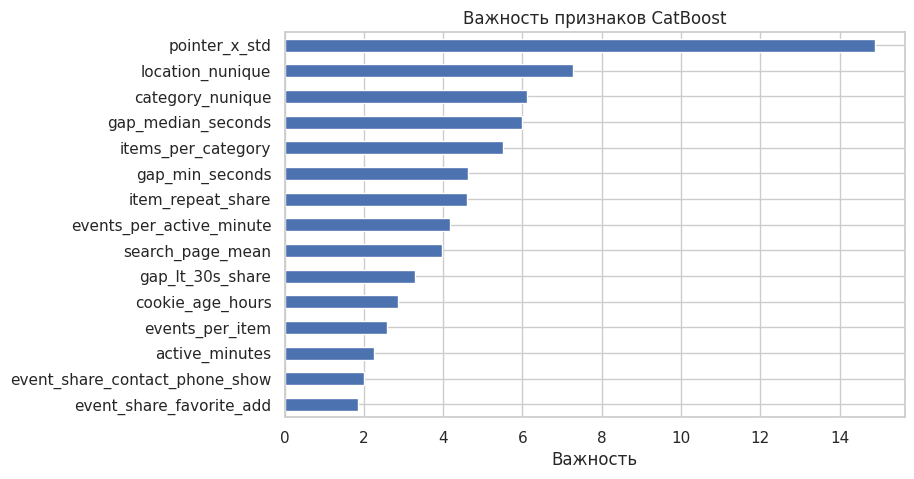

In [166]:
catboost_feature_importance = pd.Series(best_catboost_model.feature_importances_, index=feature_columns)
catboost_feature_importance = catboost_feature_importance.sort_values(ascending=False).head(15)

display(catboost_feature_importance.to_frame(name="Важность"))

catboost_feature_importance.sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("Важность признаков CatBoost")
plt.xlabel("Важность")
plt.show()

Обучим итоговый CatBoost на всем train с выбранными параметрами и получим оценки для test

In [167]:
X_full = train_features[feature_columns]
y_full = train_features["target"]
X_test = test_features[feature_columns]

final_catboost_model = CatBoostClassifier(
    iterations=best_iteration,
    loss_function="Logloss",
    random_seed=RANDOM_STATE,
    allow_writing_files=False,
    verbose=False,
    **best_params,
)

final_catboost_model.fit(X_full, y_full, cat_features=categorical_features, verbose=False)
test_scores = final_catboost_model.predict_proba(X_test)[:, 1]

print("Количество предсказаний:", len(test_scores))
print("Минимальный score:", test_scores.min())
print("Максимальный score:", test_scores.max())
print("Средний score:", test_scores.mean())

Количество предсказаний: 4909
Минимальный score: 0.0005300229034037371
Максимальный score: 0.9940885874099074
Средний score: 0.0845471743460436


Optuna провела 20 попыток на временной валидации с early stopping и выбрала параметры по Precision при Recall не ниже 70%

Лучшими стали depth=5, learning_rate=0.03, l2_leaf_reg=8, random_strength=1, bagging_temperature=1 и 355 итераций

CatBoost улучшил основной результат с 0,696 у Random Forest до 0,747. PR-AUC составил 0,754, ROC-AUC — 0,927

Итоговая модель обучена на всех 11 091 куки из train, для 4 909 куки из test рассчитаны значения test_scores

# 8. Формирование submission.csv

Сформируем submission.csv с колонками cookie_id и score. Перед сохранением проверим порядок куки, отсутствие дублей и диапазон значений от 0 до 1

In [168]:
submission = pd.DataFrame({
    "cookie_id": test_features["cookie_id"],
    "score": test_scores,
})

assert list(submission.columns) == ["cookie_id", "score"]
assert len(test_scores) == len(test_features)
assert len(submission) == len(test)
assert submission["cookie_id"].is_unique
assert submission["cookie_id"].equals(test["cookie_id"])
assert set(submission["cookie_id"]) == set(sample_submission["cookie_id"])
assert submission["score"].between(0, 1).all()

submission.to_csv("submission.csv", index=False)

display(submission.head())
print("Файл submission.csv сохранен")

files.download("submission.csv")

,cookie_id,score
0,ck_315fb710a0e371e7,0.0025
1,ck_a76ee3b3e3e522fd,0.0501
2,ck_94c9a4d382689e82,0.0490
3,ck_8eaf9509ad9462a0,0.0013
4,ck_9a88a5a989cb5bc6,0.0101


Файл submission.csv сохранен


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>